In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import math
import glob
import sys
sys.path.append("../scripts")
from TrackReconstruction_functions import *
from collections import Counter
import json
import os
import random

import torch
import torch.nn as nn
from torch.nn import Linear
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import radius_graph, GATConv, global_mean_pool, TransformerConv
from torch_geometric.utils import to_networkx
from torch_geometric.data import Batch

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

from joblib import Parallel, delayed

torch.cuda.empty_cache()
import gc
gc.collect()

%matplotlib widget

/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libcudart.so.12: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/torch_cluster/_

In [5]:
# Check for CUDA (NVIDIA) or MPS (Apple)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

scale_factor_bkg = None  # Initialize it globally or at the top
mapped_dataset=False # don't change this!
df_merged = pd.DataFrame()
mode = "GraphTransformer" # Graph Transformer Network

NVIDIA GeForce RTX 2060
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB
Using device: cuda


In [6]:
# Since we are going to do a lazy loading where we dont load in all the files at once
# We have to mix up dataset based on the file names
# This section loads in the files and then splits them up so we have a more
# uniform distribution of files loaded in at runtime.

all_files = glob.glob('/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/*/1bar/5percent/GNN_files/*.pt')

# Get the category of events in the given file
categories = {}
for f in all_files:
    # Extracts '0nubb' or 'Bi' from the path
    cat = f.split('/')[-5] 
    if cat not in categories:
        categories[cat] = []
    categories[cat].append(f)

# Sort each category, use a random seed to keep consistency
for cat in categories:
    random.seed(42)
    random.shuffle(categories[cat])

# Interleave the files with a  Zip-like mixing
mixed_files = []
max_len = max(len(v) for v in categories.values())

# Get the mixed files list
for i in range(max_len):
    for cat in categories:
        if i < len(categories[cat]):
            mixed_files.append(categories[cat][i])

print(f"First 5 mixed files:\n {mixed_files[:5]}")

First 5 mixed files:
 ['/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/ATPC_single/1bar/5percent/GNN_files/ATPC_GNN_single_chunk_56.pt', '/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/ATPC_0nubb/1bar/5percent/GNN_files/ATPC_GNN_0nubb_chunk_40.pt', '/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/ATPC_Bi_ion/1bar/5percent/GNN_files/ATPC_GNN_Bi_chunk_26.pt', '/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/ATPC_Tl_ion/1bar/5percent/GNN_files/ATPC_GNN_Tl_chunk_5.pt', '/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/ATPC_single/1bar/5percent/GNN_files/ATPC_GNN_single_chunk_44.pt']


In [ ]:
# This class will help with loading the data in at runtime to save on memory

class CategoricalShardedGNN(Dataset):
    
    # Function is called at the beginning
    def __init__(self, file_paths, one_vs_all=False, cache_path="dataset_cache.json"):
        self.file_paths = file_paths
        self.one_vs_all = one_vs_all
        
        # Internal state
        self.cumulative_sizes = []
        self.all_labels = [] # Stored once to avoid double-loading
        self.subtype_counts = Counter()
        
        # Define mapping from subtype to the right classes
        self.multi_map = {0: 3, 1: 0, 2: 1, 3: 2} # transforms binary to multiclass during training based on the subtype stored

        # If the JSON file exists then load it in. This saves us time when loading files in for the first time
        if os.path.exists(cache_path):
            print(f"Loading metadata from cache: {cache_path}")
            with open(cache_path, 'r') as f:
                cache_data = json.load(f)
                self.cumulative_sizes = cache_data['cumulative_sizes']
                self.all_labels = cache_data['all_labels']
                raw_counts = cache_data['subtype_counts']
                self.subtype_counts = Counter({int(k): v for k, v in raw_counts.items()})
        else:
            print("Indexing files for the first time (this will take a few minutes)...")
            self.cumulative_sizes = [0]
            
            # Loop over the files
            for f in self.file_paths:
                print(f)
                shard = torch.load(f, map_location='cpu')
                shard_len = len(shard)
                self.cumulative_sizes.append(self.cumulative_sizes[-1] + shard_len)
                
                # Use .item() to ensure we get a Python int, not a Tensor
                shard_subtypes = [int(d.subType.item() if torch.is_tensor(d.subType) else d.subType) for d in shard]
                shard_labels = [int(d.y.item() if torch.is_tensor(d.y) else d.y) for d in shard]
                
                self.subtype_counts.update(shard_subtypes)
                self.all_labels.extend(shard_labels)
            
            # Save to cache
            print(f"Saving metadata to {cache_path}...")
            with open(cache_path, 'w') as f:
                json.dump({
                    'cumulative_sizes': self.cumulative_sizes,
                    'all_labels': self.all_labels,
                    'subtype_counts': dict(self.subtype_counts)
                }, f)

        self.total_graphs = self.cumulative_sizes[-1]
        self.current_shard_idx = -1
        self.current_shard_data = None
        self.print_scale_factors()
    
    
    def __len__(self):
        return self.total_graphs
    
    # This function is how pytorch will access the data when looping over in a batch
    def __getitem__(self, idx):
        
        # Look at the provided graph index and find the file index
        shard_idx = np.searchsorted(self.cumulative_sizes, idx, side='right') - 1
        
        # This is the relative index of the specfic graph in the file
        within_shard_idx = idx - self.cumulative_sizes[shard_idx]

        # If I don't already have the file loaded in RAM, grab the file and load it into
        # The current file that is loaded is stored in the current_shard_index variable
        # This means we dont have to load the file again if its already open
        if shard_idx != self.current_shard_idx:
            self.current_shard_data = torch.load(self.file_paths[shard_idx])
            self.current_shard_idx = shard_idx

        graph = self.current_shard_data[within_shard_idx]

        # Dynamic remapping
        sub_type = int(graph.subType)
        
        # If one vs all mode, then we remap the data, else leave it alone as its mapped correctly
        if self.one_vs_all:
            new_y = self.multi_map.get(sub_type, 0)
            graph.y = torch.tensor([new_y], dtype=torch.long)
        
        return graph

    def print_scale_factors(self):
        # Mapping counts to your class names
        # subtype_counts keys are 0, 1, 2, 3
        sig = self.subtype_counts[0]
        bi  = self.subtype_counts[1]
        tl  = self.subtype_counts[2]
        sn  = self.subtype_counts[3]
        total_bkg = bi + tl + sn

        print(f"\n--- Dataset Summary ---")
        print(f"Signal (0nubb): {sig}")
        print(f"Background: {total_bkg}")
        
        if total_bkg > 0:
            print(f"Binary Scale Factor (Sig/Bkg): {round(sig/total_bkg, 2)}")
            
        if self.one_vs_all:
            print("\nOne-vs-All Scalings (Sig/Class):")
            print(f"Bi: {bi} | Factor: {round(sig/bi, 2) if bi > 0 else 'inf'}")
            print(f"Tl: {tl} | Factor: {round(sig/tl, 2) if tl > 0 else 'inf'}")
            print(f"Single: {sn} | Factor: {round(sig/sn, 2) if sn > 0 else 'inf'}")
    

one_vs_all = True
dataset = CategoricalShardedGNN(mixed_files, one_vs_all)

Loading metadata from cache: dataset_cache.json

--- Dataset Summary ---
Signal (0nubb): 773634
Background: 2388555
Binary Scale Factor (Sig/Bkg): 0.32

One-vs-All Scalings (Sig/Class):
Bi: 837666 | Factor: 0.92
Tl: 760001 | Factor: 1.02
Single: 790888 | Factor: 0.98


In [8]:
# 1. Create a list of all indices
indices = list(range(len(dataset)))

all_labels = dataset.all_labels

# 3. Perform the split on the INDICES
train_val_idx, test_idx = train_test_split(indices, test_size=0.10, stratify=all_labels, random_state=42)

# To get 2/9 of the remaining 90% (which equals 20% of the original total)
train_idx, val_idx = train_test_split(train_val_idx, test_size=2/9, stratify=[all_labels[i] for i in train_val_idx], random_state=42)

# Split the dataset based on the indices
train_dataset = Subset(dataset, train_idx)
val_dataset   = Subset(dataset, val_idx)
test_dataset  = Subset(dataset, test_idx)

# Sorting the indices, helps line the files up in order
train_dataset.indices.sort()
val_dataset.indices.sort()
test_dataset.indices.sort()

# 5. Create your DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=False, num_workers=15)
val_loader   = DataLoader(val_dataset,   batch_size=4096, shuffle=False, num_workers=15)
test_loader  = DataLoader(test_dataset,  batch_size=4096, shuffle=False, num_workers=15)

In [9]:
# Define the GNN
class GATNet(nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, heads=4):
        super().__init__()

        self.conv1 = GATConv(num_node_features, hidden_channels, heads=heads, concat=False) # concat False keeps hidden_channels fixed
        self.conv2 = GATConv(hidden_channels,   hidden_channels, heads=heads, concat=False)
        self.conv3 = GATConv(hidden_channels,   hidden_channels, heads=1,     concat=False)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x
    
class GATNetEdge(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, edge_dim, heads=4):
        super().__init__()

        self.conv1 = GATConv( num_node_features, hidden_channels, heads=heads, concat=False, edge_dim=edge_dim)
        self.conv2 = GATConv( hidden_channels,   hidden_channels, heads=heads, concat=False, edge_dim=edge_dim)
        self.conv3 = GATConv( hidden_channels,   hidden_channels, heads=1,     concat=False, edge_dim=edge_dim)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = getattr(data, 'edge_attr', None)
        x = F.elu(self.conv1(x, edge_index, edge_attr))
        x = F.elu(self.conv2(x, edge_index, edge_attr))
        x = self.conv3(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x
    
class EventTransformerConv(torch.nn.Module):
    def __init__(self, hidden_channels, num_classes, num_node_features, edge_dim):
        super().__init__()
        self.conv1 = TransformerConv(num_node_features, hidden_channels, edge_dim=edge_dim)
        self.conv2 = TransformerConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
        self.conv3 = TransformerConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = getattr(data, 'edge_attr', None)
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = self.conv3(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x

In [10]:
# Grab counts from the dataset object
sig = dataset.subtype_counts[0]
bi  = dataset.subtype_counts[1]
tl  = dataset.subtype_counts[2]
sn  = dataset.subtype_counts[3]
total_bkg = bi + tl + sn

# Calculate the raw factors
sf_bkg    = sig / total_bkg if total_bkg > 0 else 1.0
sf_bi     = sig / bi if bi > 0 else 1.0
sf_tl     = sig / tl if tl > 0 else 1.0
sf_single = sig / sn if sn > 0 else 1.0

if one_vs_all:
    num_classes_train = 4
    extension = "ova"
    bkg_penalty_sf = 1 
    # Order: [Bi, Tl, Single, 0nubb] based on your mapping {1:0, 2:1, 3:2, 0:3}
    train_weights = torch.tensor([
        bkg_penalty_sf * sf_bi, 
        bkg_penalty_sf * sf_tl, 
        sf_single, 
        1.0
    ]).to(device)
else:
    num_classes_train = 2 # Note: Binary classification in PyTorch CrossEntropy usually needs 2 outputs
    extension = "binary"
    # Order: [Background, Signal] based on your mapping {1:0, 2:0, 3:0, 0:1}
    train_weights = torch.tensor([sf_bkg, 1.0]).to(device)

In [11]:
def accuracy_from_logits(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()

# mode = "GAT" # Graph Attention Network
mode = "GraphTransformer" # Graph Transformer Network


# Define your ML models here
if mode == "GAT":
    model = GATNetEdge(hidden_channels=64, num_classes=num_classes_train, edge_dim=2, num_node_features = 5).to(device) # GAT + Edge Features
elif (mode == "GraphTransformer"):
    model = EventTransformerConv(hidden_channels=64, num_classes=num_classes_train, num_node_features=5, edge_dim=2).to(device) # Transformer model
else:
    print("Unknown ML network specified.")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) 
criterion = nn.CrossEntropyLoss(weight=train_weights)

train_loss_hist = []
val_loss_hist = []
val_acc_hist = []
best_val_loss=1e20
history_list = []

minibatch_size = 400

total_batches = len(train_loader)

# Calculate the 10% interval (ensure it's at least 1)
report_interval = max(1, total_batches // 10)

for epoch in range(35):

    # -------- training --------
    # Put the model in training mode, gradients will be computed
    model.train() 
    train_loss = 0.0 # Sum the loss over all batches, then average it

    # Loop over training batches
    for i, buffer_data in enumerate(train_loader):
        
        indices = torch.randperm(buffer_data.num_graphs)
        buffer_list = buffer_data.to_data_list() # Returns a list of the graphs in the batch
        
        # Loop over full batch in steps of minibatch_size
        for start_idx in range(0, len(buffer_list), minibatch_size):
        
            # Print every 10%
            if (i + 1) % report_interval == 0:
                percent_done = (i + 1) / total_batches * 100
                # print(f"Progress: {percent_done:.0f}% ({i + 1}/{total_batches} batches)")
            
            end_idx = start_idx + minibatch_size
            batch_indices = indices[start_idx:end_idx]
            
            graphs_mini_list = [buffer_list[int(idx)] for idx in batch_indices] # return only the graphs in the minibatch from buffer_list
            mini_batch = Batch.from_data_list(graphs_mini_list).to(device) # Moves the graphs to the GPU
            
            # 2. Sanity Check (Only for the first batch of the first epoch)
            # if epoch == 0 and i == 0:
            #     labels = mini_batch.y
            #     sig_count = (labels == (3 if one_vs_all else 1)).sum().item()
            #     bkg_count = len(labels) - sig_count
            #     print(f"\n--- Batch 0 Check ---")
            #     print(f"Batch Size: {len(labels)} | Signal: {sig_count} | Bkg: {bkg_count}")
            #     print(f"Label values: {torch.unique(labels).tolist()}")
            #     print(f"----------------------\n")

            optimizer.zero_grad()            # Clear old features
            logits = model(mini_batch)             # Data flows through the network, the output is called logits (raw scores not probabilities) -- forward pass
            loss = criterion(logits, mini_batch.y) # Compares the predictions (logits) with the true labels (yb)
            loss.backward()                  # Computes the gradients of the loss (stored in param.grad for every model param)
            optimizer.step()                 # Uses the gradients to update the weights. Depends on the optimizer e.g. SGD, Adam etc -- this is the learning step

            train_loss += loss.item() * mini_batch.num_graphs # Accumulates the total loss. loss.item() returns the loss for this batch. So multiply by batch size data.num_graphs 

    train_loss /= len(train_loader.dataset) # Average the training loss over the total dataset
    train_loss_hist.append(train_loss)

    # -------- validation --------
    model.eval() # Disables dropout, freezes batchnorm statistics, ensures deterministic behaviour
    val_loss = 0.0
    val_acc = 0.0

    with torch.no_grad(): # Disables gradient tracking (saves memory, speeds up evalulation, prevents accidental backpropagation)
        for data in val_loader:
            data = data.to(device) # Move the whole graph batch to GPU
            
            logits = model(data)
            loss = criterion(logits, data.y)

            val_loss += loss.item() * data.num_graphs
            val_acc += accuracy_from_logits(logits, data.y) * data.num_graphs # Converts logits -> predicted class, compares with y

    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)

    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.3f}"
    )
    
    # Saving the model 
    checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': val_loss,
    }

    if val_loss < best_val_loss:
        torch.save(checkpoint, f'../GNN_files/GNN_{mode}_{extension}_v1_all.pt')
        print("Model improved! Saving...")
        best_val_loss = val_loss
    
    # Saving the information from the training
    metrics = {
        'epoch': epoch,
        'train_loss': float(train_loss),
        'val_loss': float(val_loss),
        'val_acc': val_acc
    }
    history_list.append(metrics)

# Save the history of the training
history_df = pd.DataFrame(history_list)
history_df.to_csv(f'../GNN_files/GNN_{mode}_{extension}_train_history_all.csv', index=False)

model.eval()
test_loss = 0.0
test_acc = 0.0

with torch.no_grad():
    for data in test_loader:
        
        data = data.to(device) # Move the whole graph batch to GPU
        
        logits = model(data)
        loss = criterion(logits, data.y)

        test_loss += loss.item() * data.num_graphs
        test_acc  += accuracy_from_logits(logits, data.y) * data.num_graphs

test_loss /= len(test_loader.dataset)
test_acc  /= len(test_loader.dataset)

print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.3f}")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fd37023d370>>
Traceback (most recent call last):
  File "/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 

KeyboardInterrupt: 


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fd37023d370>>
Traceback (most recent call last):
  File "/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    

def _clean_thread_parent_frames(
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fd37023d370>>Exception ignored in: 
Traceback (most recent call last):
<bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fd37023d370>>  File "/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames

    Traceback (most recent call last):
  File "/home/argon/Projects/Krishan/venv/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
def _clean_thread_parent_frames(
    KeyboardInterruptdef _clean_thread_parent_frames(: 
KeyboardInterrupt
: 


In [12]:
# Load in the best model during training and the training history
# Define your ML models here
if mode == "GAT":
    model = GATNetEdge(hidden_channels=64, num_classes=num_classes_train, edge_dim=2, num_node_features = 5).to(device) # GAT + Edge Features
elif (mode == "GraphTransformer"):
    model = EventTransformerConv(hidden_channels=64, num_classes=num_classes_train, num_node_features=5, edge_dim=2).to(device) # Transformer model
else:
    print("Unknown ML network specified.")


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=train_weights) # [background, signal]

checkpoint = torch.load(f'../GNN_files/GNN_{mode}_{extension}_v1_all.pt', map_location=device)

# 4. Restore the states
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']


history_df = pd.read_csv(f"../GNN_files/GNN_{mode}_{extension}_train_history_all.csv")
display(history_df)

,epoch,train_loss,val_loss,val_acc
0,0,1.260676,1.120388,0.461399
1,1,1.025650,0.874006,0.621384
2,2,0.916647,0.841970,0.643916
3,3,0.886656,0.815785,0.664868
4,4,0.866508,0.792545,0.676556
5,5,0.850560,0.817151,0.668065
6,6,0.840607,0.776824,0.689291
7,7,0.832320,0.787554,0.686714
8,8,0.824783,0.760949,0.695731
9,9,0.820552,0.773935,0.692487


In [13]:
class_names = ['0nubb', 'Bi', 'Tl', 'single']
def compute_roc(model, loader, device, one_vs_all):
    model.eval()
    y_true, y_score, event_ids, subTypes = [], [], [], []

    with torch.no_grad():
        # Loops over in batches specified in dataloader, returns array of length of the batch size. 
        for data in loader:
            data = data.to(device)
            logits = model(data)
            probs = torch.softmax(logits, dim=1) # List of length batch size, N row for each classification category
            
            if (one_vs_all):
                p_signal = probs[:, 3].cpu() # Get the signal column probs
            else:
                p_signal = probs[:, 1].cpu() # Get the signal column probs
            
            y        = data.y.cpu()      # Get the y labels
            
            y_score.append(p_signal)
            y_true.append(y)
            subTypes.append(data.subType.cpu())
            event_ids.append(data.event_id.cpu())

    y_true  = torch.cat(y_true).numpy()
    y_score = torch.cat(y_score).numpy()
    event_ids = torch.cat(event_ids).numpy()
    subTypes = torch.cat(subTypes).numpy()
        
    df_scores = pd.DataFrame({"event_id":event_ids, "y_score":y_score, "y_true":y_true, "subTypes" : subTypes})
    
    mapping = {i: name for i, name in enumerate(class_names)}
    df_scores['subTypes'] = df_scores['subTypes'].map(mapping)

    if (one_vs_all):
        y_true_ova = (y_true == 3).astype(int)
        fpr, tpr, _ = roc_curve(y_true_ova, y_score)
    else:
        fpr, tpr, _ = roc_curve(y_true, y_score)
    
    return fpr, tpr, auc(fpr, tpr), df_scores

fpr_tr,   tpr_tr,  auc_tr,   df_scores_tr  = compute_roc(model, train_loader, device, one_vs_all)
fpr_va,   tpr_va,  auc_va,   df_scores_va  = compute_roc(model, val_loader,   device, one_vs_all)
fpr_tst,  tpr_tst, auc_tst,  df_scores_tst = compute_roc(model, test_loader,  device, one_vs_all)
df_scores_all = pd.concat([df_scores_tr, df_scores_va, df_scores_tst])
display(df_scores_all)

,event_id,y_score,y_true,subTypes
0,94185013,0.000037,2,single
1,94185016,0.097312,2,single
2,94185035,0.825804,2,single
3,94185037,0.006418,2,single
4,94185038,0.167552,2,single
...,...,...,...,...
316214,2686000839,0.017127,1,Tl
316215,2686000840,0.003261,1,Tl
316216,2686001166,0.000038,1,Tl
316217,2686001258,0.027645,1,Tl


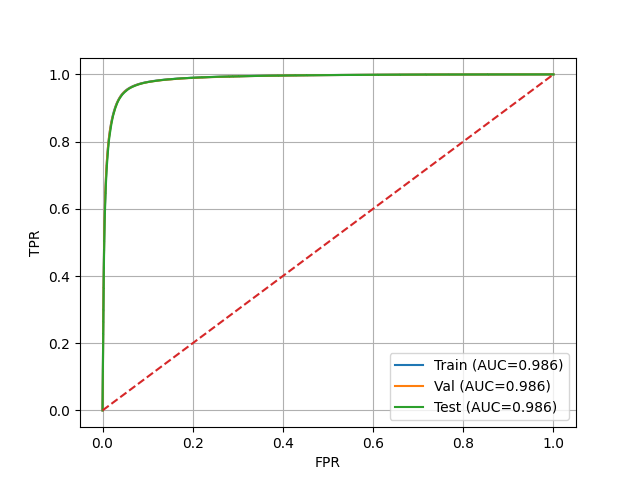

Val AUC: 0.986 


In [14]:
plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"Train (AUC={auc_tr:.3f})")
plt.plot(fpr_va, tpr_va, label=f"Val (AUC={auc_va:.3f})")
plt.plot(fpr_tst, tpr_tst, label=f"Test (AUC={auc_va:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()
print(f"Val AUC: {auc_va:.3f} ")


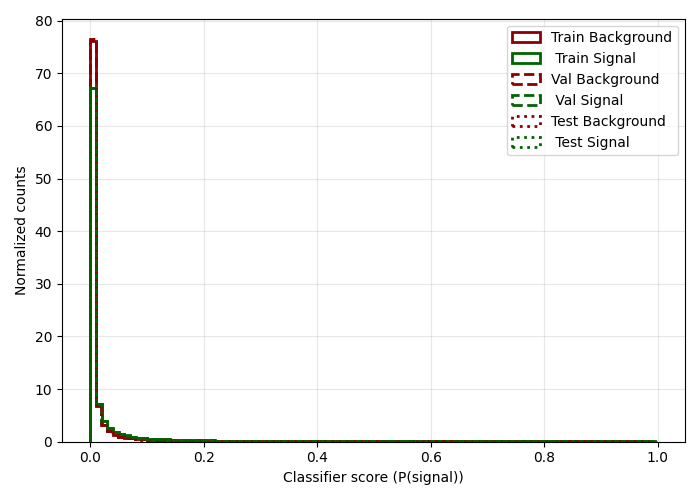

0.034089959482657764 0.981098709080646


In [23]:
plt.figure(figsize=(7,5))

bins = 100


plt.hist(df_scores_tr[df_scores_tr.y_true == 1].y_score, bins=bins, density=True, histtype='step', linewidth=2, label='Train Background', linestyle = "-", color = "darkred")
plt.hist(df_scores_tr[df_scores_tr.y_true == 0].y_score, bins=bins, density=True, histtype='step', linewidth=2, label=' Train Signal',    linestyle = "-", color = "darkgreen")

plt.hist(df_scores_va[df_scores_va.y_true == 1].y_score, bins=bins, density=True, histtype='step', linewidth=2, label='Val Background', linestyle = "--", color = "darkred")
plt.hist(df_scores_va[df_scores_va.y_true == 0].y_score, bins=bins, density=True, histtype='step', linewidth=2, label=' Val Signal',    linestyle = "--", color = "darkgreen")

plt.hist(df_scores_tst[df_scores_tst.y_true == 1].y_score, bins=bins, density=True, histtype='step', linewidth=2, label='Test Background', linestyle = ":", color = "darkred")
plt.hist(df_scores_tst[df_scores_tst.y_true == 0].y_score, bins=bins, density=True, histtype='step', linewidth=2, label=' Test Signal',    linestyle = ":", color = "darkgreen")


plt.xlabel("Classifier score (P(signal))")
plt.ylabel("Normalized counts")
plt.legend()
plt.grid(alpha=0.3)

# plt.semilogy()
plt.tight_layout()
plt.show()

cut = 0.6
signal_eff = len(df_scores_all[ (df_scores_all.y_true == 0) & (df_scores_all.y_score > cut)])/len(df_scores_all[ (df_scores_all.y_true == 0)])
bkg_rej = 1 - len(df_scores_all[ (df_scores_all.y_true == 1) & (df_scores_all.y_score > cut)])/len(df_scores_all[ (df_scores_all.y_true == 1)])
print(signal_eff, bkg_rej)

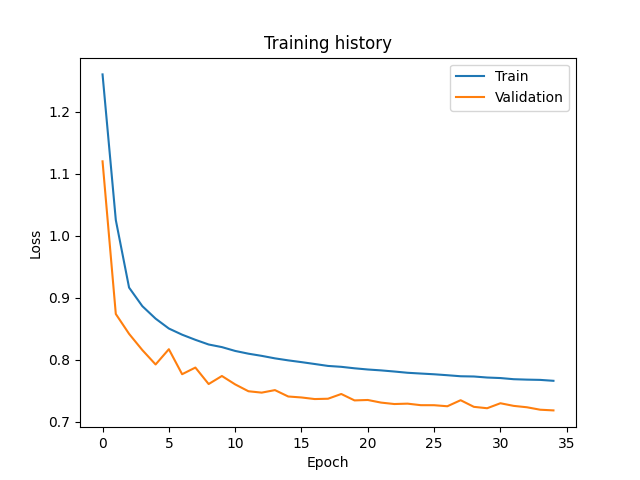

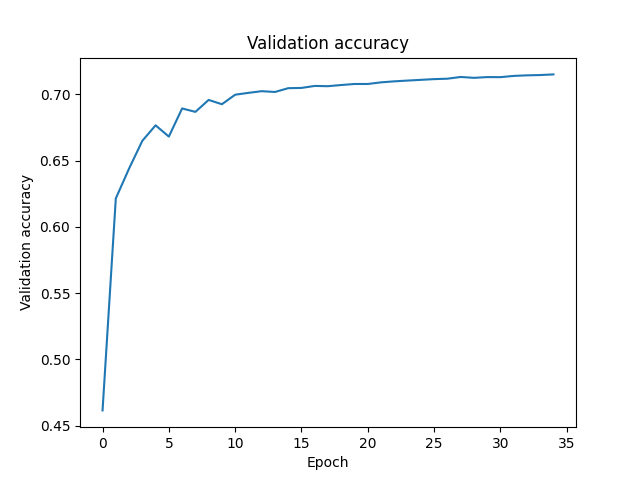

In [16]:
plt.figure()
plt.plot(history_df.train_loss, label='Train')
plt.plot(history_df.val_loss, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training history')
plt.show()

plt.figure()
plt.plot(history_df.val_acc)
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Validation accuracy')
plt.show()

Cut =  0.955
Signal Eff:   0.57
Bkg Eff, Bkg Rej, Bkg Rej Fact
Tl ERej:      0.0014 0.9986 719.02
Bi ERej:      0.0048 0.9952 208.27
single ERej:  0.0077 0.9923 129.23


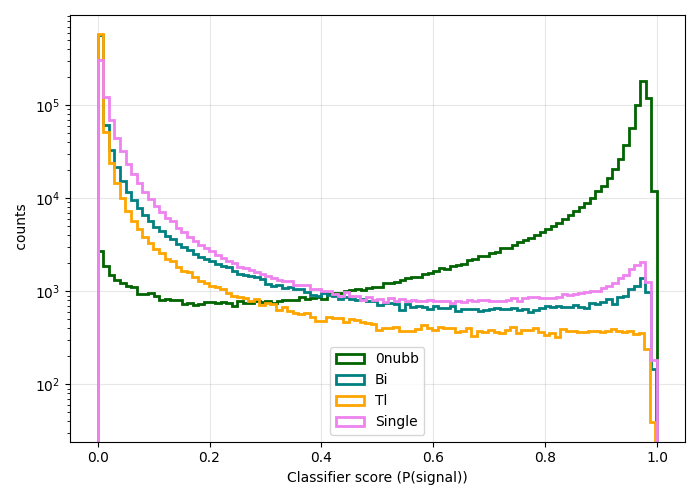

In [17]:
def CalcEfficiency(df, label, cut):
    num = len(df[ (df.subTypes == label) & (df.y_score > cut)])
    den = len(df[ (df.subTypes == label)])
    return num/den

cut = 0.955

print("Cut = ", cut)
print(f"Signal Eff:   {CalcEfficiency(df_scores_all, '0nubb', cut):.2f}")

print("Bkg Eff, Bkg Rej, Bkg Rej Fact")
tl_eff = CalcEfficiency(df_scores_all, "Tl", cut)
print(f"Tl ERej:      {tl_eff:.4f} {1-tl_eff:.4f} {1/tl_eff:.2f}")

bi_eff = CalcEfficiency(df_scores_all, "Bi", cut)
print(f"Bi ERej:      {bi_eff:.4f} {1-bi_eff:.4f} {1/bi_eff:.2f}")

s_eff = CalcEfficiency(df_scores_all, "single", cut)
print(f"single ERej:  {s_eff:.4f} {1-s_eff:.4f} {1/s_eff:.2f}")

plt.figure(figsize=(7,5))

bins = 100

plt.hist(df_scores_all[ (df_scores_all.subTypes == "0nubb")].y_score,  bins=bins, density=False, histtype='step', linewidth=2, label='0nubb',  color = "darkgreen");
plt.hist(df_scores_all[ (df_scores_all.subTypes == "Bi")].y_score,     bins=bins, density=False, histtype='step', linewidth=2, label='Bi',     color = "Teal");
plt.hist(df_scores_all[ (df_scores_all.subTypes == "Tl")].y_score,     bins=bins, density=False, histtype='step', linewidth=2, label='Tl',     color = "Orange");
plt.hist(df_scores_all[ (df_scores_all.subTypes == "single")].y_score, bins=bins, density=False, histtype='step', linewidth=2, label='Single', color = "violet");


plt.xlabel("Classifier score (P(signal))")
plt.ylabel(" counts")
plt.legend()
plt.grid(alpha=0.3)

plt.semilogy()
plt.tight_layout()
plt.show()

In [18]:
df_out = df_scores_all.copy()
df_out['subType'] = df_out['subTypes'].replace({'0nubb': 'ATPC_0nubb', 'Bi': 'ATPC_Bi_ion', 'Tl': 'ATPC_Tl_ion', 'single': 'ATPC_single'})
df_out = df_out[["event_id", "subType", "y_score"]]
df_out = df_out[df_out.y_score > cut]
display(df_out)


# df_out[["event_id", "subType"]].to_csv("../eventlists/ATPC_1bar_5percent_GNN.csv", index=False)

# print(len(df_out[df_out.subType == "ATPC_0nubb"]))
# print(len(df_out[df_out.subType == "ATPC_Bi_ion"]))
# print(len(df_out[df_out.subType == "ATPC_Tl_ion"]))
# print(len(df_out[df_out.subType == "ATPC_single"]))


,event_id,subType,y_score
47,94185508,ATPC_single,0.955162
257,94207140,ATPC_single,0.955422
317,94227527,ATPC_single,0.971623
319,94227550,ATPC_single,0.962560
429,94248328,ATPC_single,0.969830
...,...,...,...
314581,926305,ATPC_0nubb,0.967412
314582,926312,ATPC_0nubb,0.967026
314681,30180000078,ATPC_Bi_ion,0.983852
315467,2610001331,ATPC_Tl_ion,0.964702


In [ ]:
# Load in the MC true for all events
def process_single_file(f):
    """Worker function for one file"""
    try:
        part = pd.read_hdf(f, "MC/particles", columns=["event_id","primary","particle_id", "initial_z", "final_z", "kin_energy"])
        return part[part.primary == 1]
    except Exception as e:
        print(f"Error in {f}: {e}")
        return None

def LoadFilesParallel(filepath):
    files = glob.glob(filepath)
    
    # n_jobs=-1 uses all available cores (all 60)
    # prefer="threads" is good for I/O, but "processes" is better for pandas filtering
    results = Parallel(n_jobs=-1, verbose=10)( delayed(process_single_file)(f) for f in files)
    
    # Filter out None results if any files failed to load
    results = [res for res in results if res is not None]
    
    return pd.concat(results)

category_to_study="ATPC_0nubb"
# category_to_study="ATPC_single"

nubb_1bar_highstats = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples/{category_to_study}/1bar/nexus/*.h5")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 185 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 237 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 293 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 322 tasks      | elapsed:   10.8s
[Parallel(n_jobs=-1)]: Done 353 tasks      | elapsed:  

In [20]:
# Function gives the lowest energy electron as the final position
# Then normalizes so its range is from 0->1
def GetBlob2Pos(df, shift):
    
    # Order by event id and reset the indexes
    df = df.sort_values("event_id")
    df = df.reset_index(drop=True)
    
    idx = df.groupby('event_id')['kin_energy'].idxmin()
    lowest_energy_particles = df.loc[idx]
    
    lowest_energy_particles["norm_zi"] = (lowest_energy_particles.initial_z + shift)/ (shift*2.0)
    lowest_energy_particles["norm_zf"] = (lowest_energy_particles.final_z + shift)/ (shift*2.0)
    
    return lowest_energy_particles

# Adds the asymetry as a df column
def CalcAsymmetry(df, category_to_study):
    
    if (category_to_study != "ATPC_0nubb"):
        return df
    
    # 1. Pivot or Filter to get energies per event
    # We use a pivot to align particle_id 1 and 2 side-by-side for every event_id
    energies = df.pivot(index='event_id', columns='particle_id', values='kin_energy')
    
    asymmetry = np.abs((energies[1] - energies[2]) / (energies[1] + energies[2]))

    df['A'] = df['event_id'].map(asymmetry)
    
    return df

nubb_1bar_highstats_norm = nubb_1bar_highstats

if (category_to_study == "ATPC_0nubb"):
    nubb_1bar_highstats_norm  = CalcAsymmetry(nubb_1bar_highstats_norm, category_to_study)

nubb_1bar_highstats_norm  = GetBlob2Pos(nubb_1bar_highstats_norm,  3100.)

display(nubb_1bar_highstats_norm)

,event_id,primary,particle_id,initial_z,final_z,kin_energy,A,norm_zi,norm_zf
1,30801,1,1,-793.338562,-879.155945,0.330876,0.730758,0.372042,0.358201
3,30803,1,1,-2582.087646,-2568.735596,0.101071,0.917756,0.083534,0.085688
4,30805,1,2,-496.527008,-304.158630,0.960754,0.218210,0.419915,0.450942
7,30806,1,1,222.822800,250.438065,0.511793,0.583541,0.535939,0.540393
8,30808,1,2,2116.041016,2170.171387,0.423556,0.655342,0.841297,0.850028
...,...,...,...,...,...,...,...,...,...
1551720,2450204,1,2,-1961.416626,-1999.545532,0.882019,0.282278,0.183642,0.177493
1551723,2450205,1,2,1022.709717,1261.817139,0.937353,0.237251,0.664953,0.703519
1551724,2450206,1,1,1526.121948,1511.392578,0.225970,0.816123,0.746149,0.743773
1551727,2450207,1,1,-100.120369,52.205341,1.078914,0.122060,0.483852,0.508420


In [21]:
selected_events = df_out[df_out.subType == category_to_study].event_id.unique()

nubb_1bar_highstats_selected = nubb_1bar_highstats_norm[nubb_1bar_highstats_norm.event_id.isin(selected_events)]

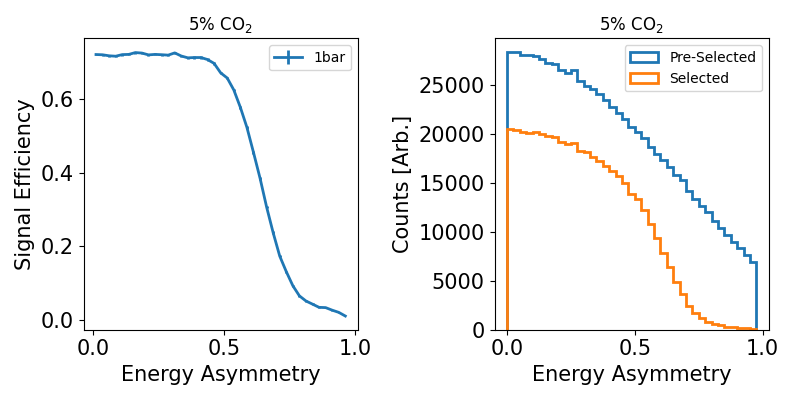

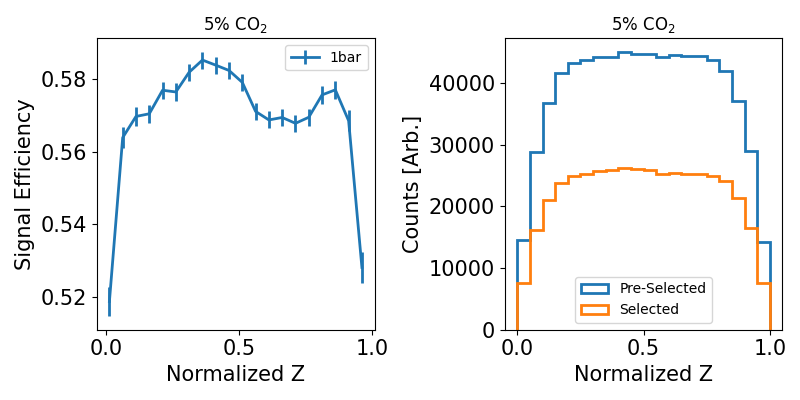

In [22]:
def CalcEfficiency(n, N, correct):
    efficiency = n/N
    
    # This corrects by applying energy resolution cut
    if correct:
        efficiency = 0.82*efficiency
    
    error=np.sqrt( (efficiency/N) * (1-efficiency)  )
    return efficiency, error

def GetHistogram(df_true, df_true_selected, var, bins):
        
    # Distribution before cuts
    n_gen, bins = np.histogram( df_true[f"{var}"],      bins = bins);
    n_sel, _    = np.histogram( df_true_selected[f"{var}"], bins = bins);
    efficiency, error = CalcEfficiency(n_sel, n_gen, False)
    
    bin_centers = bins+0.025/2.0
    bin_centers = bin_centers[:-1]
    
    return efficiency, error, bin_centers


if (category_to_study == "ATPC_0nubb"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    eff,  err,  bins  = GetHistogram(nubb_1bar_highstats_norm,  nubb_1bar_highstats_selected,  "A", np.arange(0,1,0.025))
    ax1.errorbar(bins, eff, yerr=err, linewidth = 2, label = "1bar")
    ax1.set_xlabel("Energy Asymmetry", fontsize=15);
    ax1.set_ylabel("Signal Efficiency", fontsize=15);
    ax1.tick_params(axis='both', labelsize=15)
    ax1.legend()
    ax1.set_title(r"5% CO$_2$")
    plt.tight_layout()
    
    ax2.hist(nubb_1bar_highstats_norm.A, bins = np.arange(0,1,0.025), linewidth = 2, histtype = "step", density=False, label = "Pre-Selected")
    ax2.hist(nubb_1bar_highstats_selected.A, bins = np.arange(0,1,0.025), linewidth = 2, histtype = "step", density=False, label = "Selected")
    ax2.set_xlabel("Energy Asymmetry", fontsize=15);
    ax2.set_ylabel("Counts [Arb.]", fontsize=15);
    ax2.tick_params(axis='both', labelsize=15)
    ax2.legend()
    ax2.set_title(r"5% CO$_2$")
    plt.tight_layout()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
eff,  err,  bins  = GetHistogram(nubb_1bar_highstats_norm,  nubb_1bar_highstats_selected,  "norm_zf", np.arange(0,1.05,0.05))
ax1.errorbar(bins, eff, yerr=err, linewidth = 2, label = "1bar")
ax1.set_xlabel("Normalized Z", fontsize=15);
ax1.set_ylabel("Signal Efficiency", fontsize=15);
ax1.tick_params(axis='both', labelsize=15)
ax1.legend()
ax1.set_title(r"5% CO$_2$")
plt.tight_layout()

ax2.hist(nubb_1bar_highstats_norm.norm_zf, bins = np.arange(0,1.05,0.05), linewidth = 2, histtype = "step", density=False, label = "Pre-Selected")
ax2.hist(nubb_1bar_highstats_selected.norm_zf, bins = np.arange(0,1.05,0.05), linewidth = 2, histtype = "step", density=False, label = "Selected")
ax2.set_xlabel("Normalized Z", fontsize=15);
ax2.set_ylabel("Counts [Arb.]", fontsize=15);
ax2.tick_params(axis='both', labelsize=15)
ax2.legend()
ax2.set_title(r"5% CO$_2$")
plt.tight_layout()